# Phase 1: Exploratory Data Analysis (EDA)
In this notebook, we load the cleanly imputed data and begin addressing our primary exploratory questions. **NOTE**: We are intentionally avoiding auto-profilers (like D-Tale) to prevent watermark injections.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set visualization style
sns.set_theme(style='whitegrid')

In [ ]:
try:
    df = pd.read_csv('data/Dataset_Cleaned_Imputed.csv')
    print(f'Data loaded successfully! Shape: {df.shape}')
except FileNotFoundError:
    print('Error: Dataset_Cleaned_Imputed.csv not found. Please run p1_data_cleaning.ipynb first!')

Data loaded successfully! Shape: (410, 57)


### 1. Demographic Distributions
Let's examine the demographic breakdown of the mothers in the dataset.

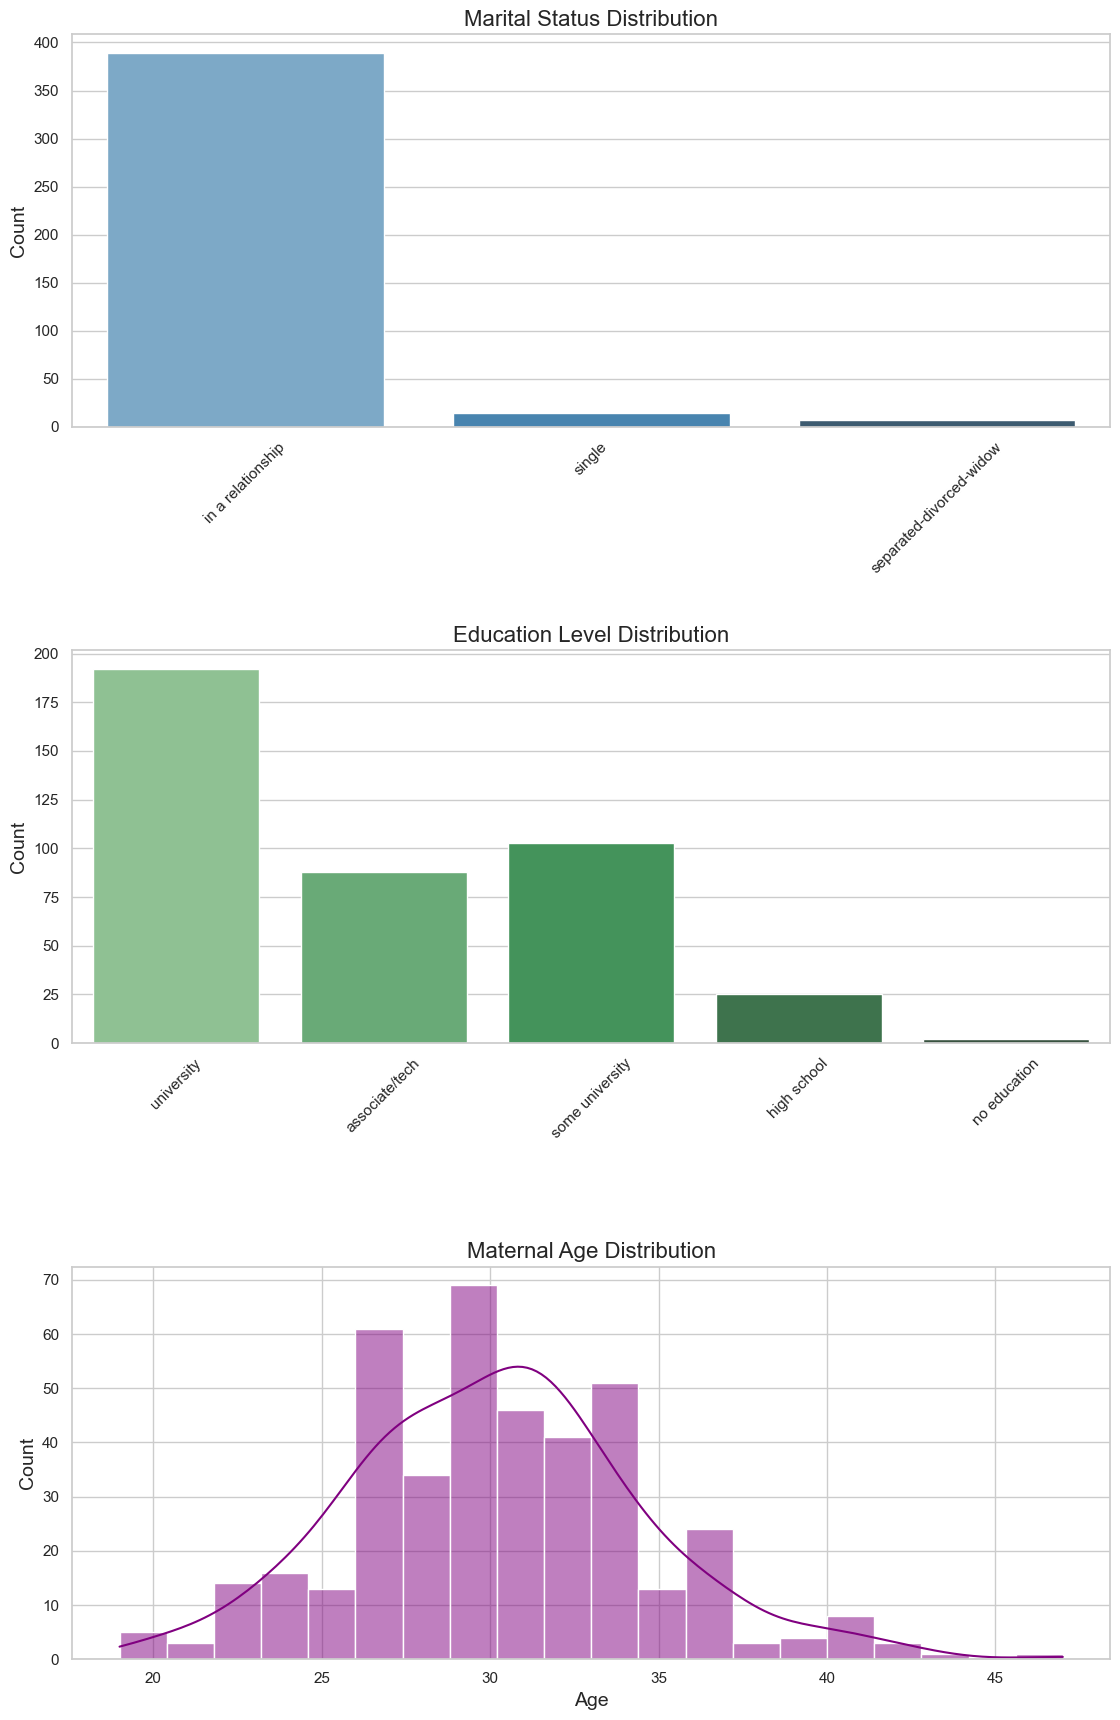

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

sns.countplot(data=df, x='marital_status', ax=axes[0], hue='marital_status', palette='Blues_d', legend=False)
axes[0].set_title('Marital Status Distribution', fontsize=16)
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)

sns.countplot(data=df, x='education', ax=axes[1], hue='education', palette='Greens_d', legend=False)
axes[1].set_title('Education Level Distribution', fontsize=16)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)

sns.histplot(data=df, x='age', bins=20, ax=axes[2], kde=True, color='purple')
axes[2].set_title('Maternal Age Distribution', fontsize=16)
axes[2].set_xlabel('Age', fontsize=14)
axes[2].set_ylabel('Count', fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()

### 2. Infant Sleep Diagnostics
How does infant sleep distribute across the dataset? This includes `sleep_night_duration_bb1` and `night_awakening_number_bb1`.

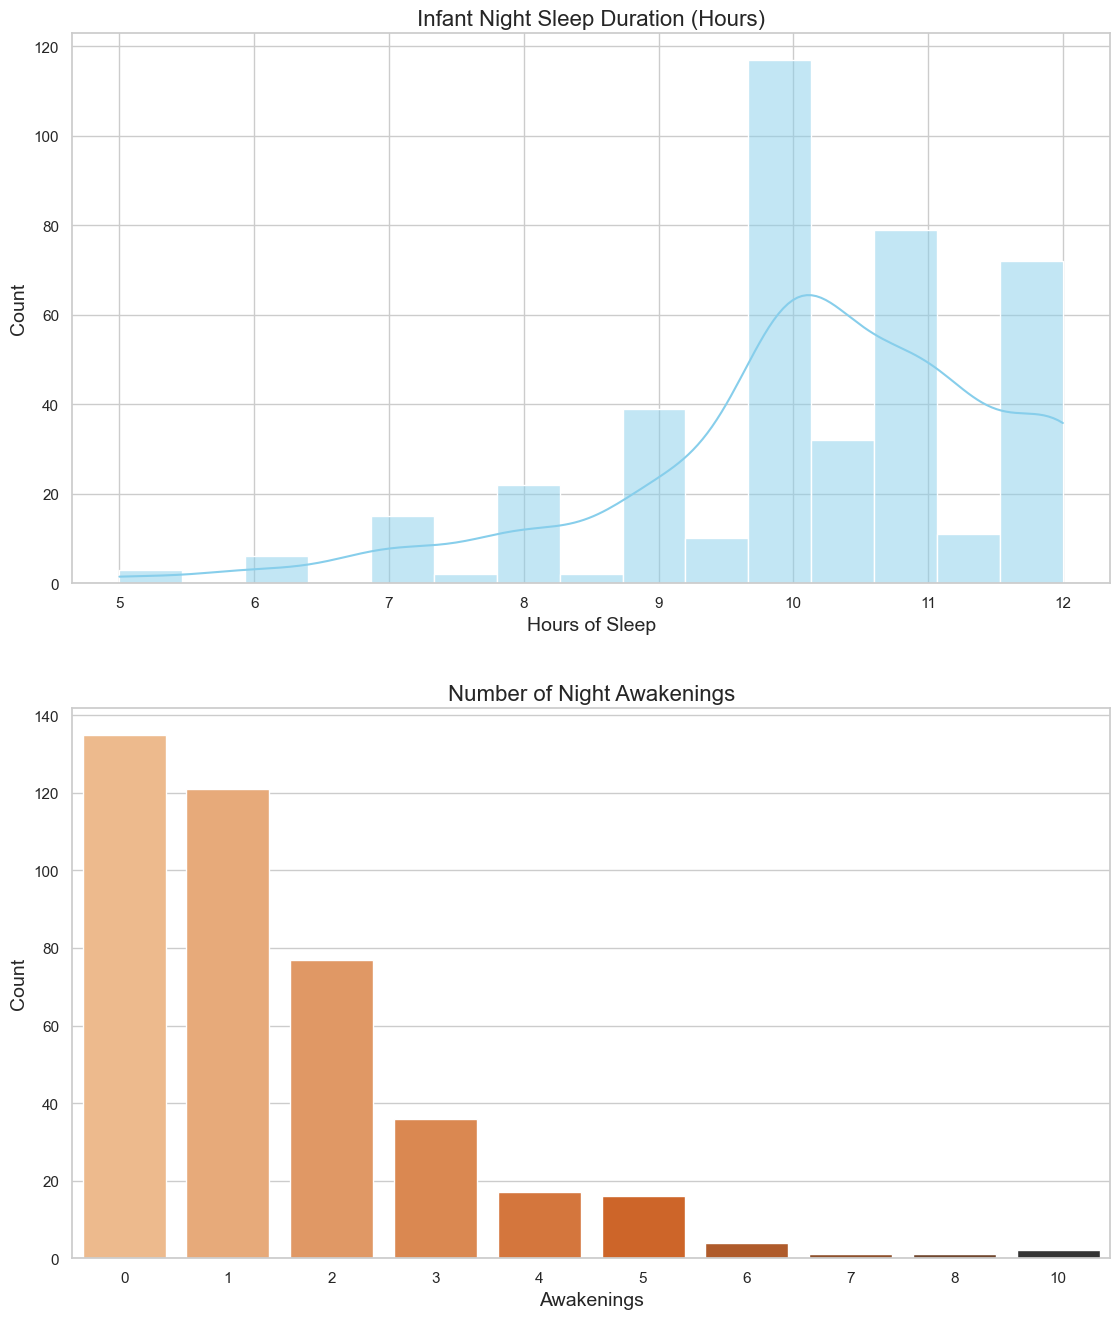

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

sns.histplot(data=df, x='sleep_night_duration_bb1', bins=15, ax=axes[0], kde=True, color='skyblue')
axes[0].set_title('Infant Night Sleep Duration (Hours)', fontsize=16)
axes[0].set_xlabel('Hours of Sleep', fontsize=14)
axes[0].set_ylabel('Count', fontsize=14)

sns.countplot(data=df, x='night_awakening_number_bb1', ax=axes[1], hue='night_awakening_number_bb1', palette='Oranges_d', legend=False)
axes[1].set_title('Number of Night Awakenings', fontsize=16)
axes[1].set_xlabel('Awakenings', fontsize=14)
axes[1].set_ylabel('Count', fontsize=14)

plt.tight_layout(pad=3.0)
plt.show()

### 3. Survey Feature Correlation (Pre-Scoring)
Let's look at how the raw survey answers (CBTS, HADS, EPDS, IBQ) correlate with each other before we officially score them in Phase 4. We will focus specifically on the IBQ (Infant Behavior Questionnaire) variables since infant temperament is a major predictive hypothesis.

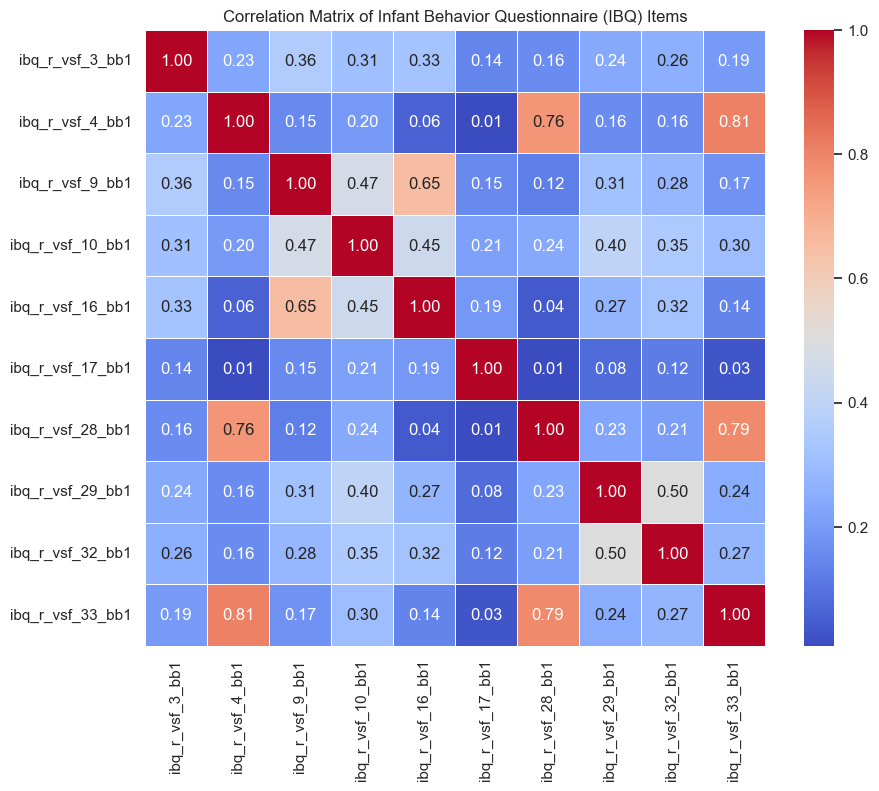

In [6]:
# Extract numerical columns to avoid correlation errors with strings
numeric_df = df.select_dtypes(include=[np.number])

# Extract IBQ columns
ibq_cols = [c for c in numeric_df.columns if c.startswith('ibq_r_')]
if ibq_cols:
    corr_matrix = numeric_df[ibq_cols].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.title('Correlation Matrix of Infant Behavior Questionnaire (IBQ) Items')
    plt.show()